# 목차
- 분석 목적
- 전처리
- EDA 분석
- 고객 단위 RFM + 확장 피처 생성
- RFM 테이블
- RMF 점수화 
- 세그먼트 정의
- 세그먼트별 매출 기여도 + 시각화
- 코호트 분석
- 재구매 예측 모델

# 분석 목적
- 고객 구매 데이터를 기반으로 RFM 분석을 수행한다.
- 고객을 세그먼트화하여 매출 기여도를 파악한다.
- 고가치 고객군과 이탈 위험 고객군을 식별한다.

In [ ]:
import pandas as pd
import datetime as dt

# 데이터 로드
df = pd.read_excel("Online Retail.xlsx")

print("데이터 크기:", df.shape)
df.head()

# 전처리
- Quantity > 0 : 반품 제거
- UnitPrice > 0 : 무료 샘플 제거
- 상위 1% 제거 : 극단적 이상치로 인한 왜곡 방지
- UK 데이터만 사용 : 동일 시장 기준 분석

In [ ]:
# CustomerID가 없는 행 제거
df = df.dropna(subset=["CustomerID"])

In [ ]:
# 중복 제거 - 동일한 주문번호(InvoiceNo)와 상품코드(StockCode)가 여러 번 나타나는 경우가 있을 수 있으므로, 중복된 행을 제거하여 고유한 주문-상품 조합만 남도록 함
df = df.drop_duplicates()

In [ ]:
# 수량이 0 이하이거나 단가가 0 이하인 행 제거 - 구매가 이루어지지 않은 거래이거나, 데이터 오류로 인해 잘못된 값이 입력된 경우가 있을 수 있으므로, 이러한 행을 제거하여 분석의 정확성을 높임
df = df[df["Quantity"] > 0]

In [ ]:
# 단가가 0 이하인 데이터 제거 - 비정상적인 거래 제거를 목적으로 사용
df = df[df["UnitPrice"] > 0]

In [ ]:
# 환불 주문 제거 (InvoiceNo가 C로 시작하는 경우) - 문자 C로 시작하는 취소 주문을 판별하기 위해
df["InvoiceNo"] = df["InvoiceNo"].astype(str)


In [ ]:
# InvoiceNo가 C로 시작하는 취소 주문 제거
df = df[~df["InvoiceNo"].str.startswith("C")]

In [ ]:
# 영국 데이터만 사용 (데이터 편차를 줄이고 일관성 있는 분석을 위해)
df = df[df["Country"] == "United Kingdom"]

In [ ]:
# 날짜 형식 변환 InvoiceDate를 datetime 형식으로 변환 (시간 계산을 가능하게 하기 위해)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
# 구매 연도 추출
df["Year"] = df["InvoiceDate"].dt.year

In [ ]:
# 구매 월 추출
df["Month"] = df["InvoiceDate"].dt.month

In [ ]:
# 총 매출 계산 (구매 수량 × 단가를 계산하여 총 구매 금액 변수를 생성하는 코드) - TotalAmount라는 새로운 열을 생성하여, Quantity와 UnitPrice를 곱한 값을 저장함으로써 각 거래의 총 매출을 계산하는 코드
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
# StockCode 문자형 변환 (상품 코드를 문자열 형태로 변환) 문자 포함 여부를 판별하기 위해서 사용
df["StockCode"] = df["StockCode"].astype(str)

In [ ]:
# POST 제거 배송비(POST) 관련 항목 제거 - 실제 상품 구매 분석을 위해서 배송비 관련 항목 제거하는 코드
df = df[~df["StockCode"].str.contains("POST", na=False)]

In [ ]:
# 문자로 구성된 비정상 상품코드 제거를 위한 코드 -> 정상 상품 코드만 분석하기 위해서
df = df[~df["StockCode"].str.contains("[A-Za-z]", regex=True)]

In [ ]:
# 단가의 상위 1% 기준값 계산 - 구매 단가가 비정상적으로 높은 거래를 제거하기 위해서 단가의 상위 1% 기준값을 계산하여 이상치를 제거하는 코드
price_limit = df["UnitPrice"].quantile(0.99)

In [ ]:
# 수량의 상위 1% 기준값 계산 - 구매 수량이 비정상적으로 높은 거래를 제거하기 위해서 수량의 상위 1% 기준값을 계산하여 이상치를 제거하는 코드
quantity_limit = df["Quantity"].quantile(0.99)

In [ ]:
# 단가가 상위 1%를 초과하는 값 제거
df = df[df["UnitPrice"] < price_limit]

In [ ]:
# 수량이 상위 1%를 초과하는 값 제거
df = df[df["Quantity"] < quantity_limit]

In [ ]:
print("전처리 끝!")
print("데이터 크기:", df.shape)

전처리 끝!
데이터 크기: (305620, 18)


# EDA (탐색적 데이터 분석)

전처리 완료 후 데이터 구조 및 분포를 확인한다.

In [ ]:
# 데이터 기본 정보 - 각 거래는 주문번호, 상품코드, 수량, 단가, 고객ID, 구매일자 등의 정보를 포함하고 있습니다. 이를 기반으로 고객 단위 분석이 가능합니다.
df.shape
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,TotalAmount,FirstPurchase,CohortMonth,OrderMonth,CohortIndex,NextPurchase,DaysToNext,Repurchase_30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,20.34,2010-12-01 08:26:00,2010-12,2010-12,0,2010-12-01 08:26:00,0.0,True
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,2010,12,15.30,2010-12-01 08:26:00,2010-12,2010-12,0,2010-12-01 08:26:00,0.0,True
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,2010,12,25.50,2010-12-01 08:26:00,2010-12,2010-12,0,2010-12-01 08:28:00,0.0,True
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,2010,12,11.10,2010-12-01 08:26:00,2010-12,2010-12,0,2010-12-01 08:28:00,0.0,True
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,2010,12,11.10,2010-12-01 08:26:00,2010-12,2010-12,0,2010-12-01 09:01:00,0.0,True


<Axes: >

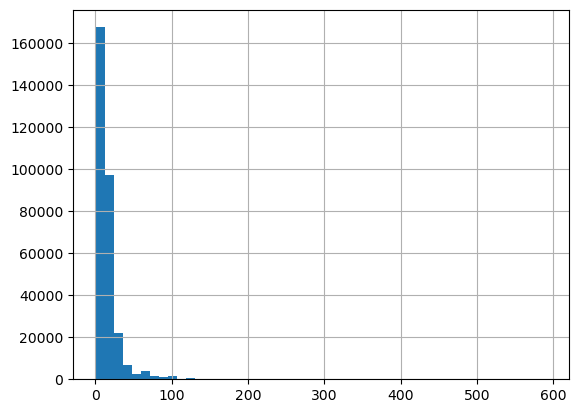

In [ ]:
# 매출 분포표 
df["TotalAmount"].hist(bins=50)

### 가로축: 한번 거래할떄의 구매금액 - 왼쪽 = 낮은 금액, 오른쪽 = 높은 금액
### 세로축: 거래 횟수 - 높을수록 많은 거래가 그 금액대에서 발생했다는 의미
### 이 그래프는 대부분의 거래가 낮은 금액대에서 발생하고, 높은 금액대에서는 거래 횟수가 급격히 줄어드는 것을 보여줍니다. 이는 일반적으로 소액 거래가 많고, 고액 거래는 드물다는 것을 나타냅니다.

<Axes: xlabel='Year,Month'>

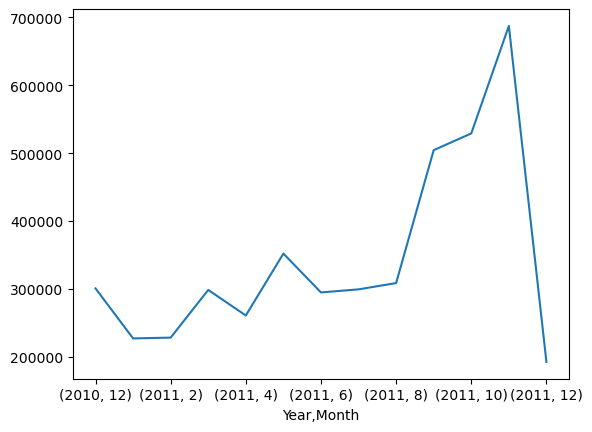

In [ ]:
# 월별 매출 추이 그래프
monthly_sales = df.groupby(["Year","Month"])["TotalAmount"].sum()
monthly_sales.plot()

# 가로축: 연도 + 월 위를 나타냄 = 2010년-12월, 2011년-01월, 2011년-02월 등등
# 세로축: 월별 총 매출액 - 해당 월의 총 매출이 높을수록 그래프가 높게 나타남
# 이 그래프는 월별 매출의 추이를 보여줍니다. 특정 시점에서 매출이 급증하거나 감소하는 패턴을 확인할 수 있으며, 계절성이나 프로모션 효과 등을 분석하는 데 도움이 된다.

### 가로축: 연도 + 월 위를 나타냄 = 2010년-12월, 2011년-01월, 2011년-02월 등등
### 세로축: 월별 총 매출액 - 해당 월의 총 매출이 높을수록 그래프가 높게 나타남
### 이 그래프는 월별 매출의 추이를 보여줍니다. 특정 시점에서 매출이 급증하거나 감소하는 패턴을 확인할 수 있으며, 계절성이나 프로모션 효과 등을 분석하는 데 도움이 된다.

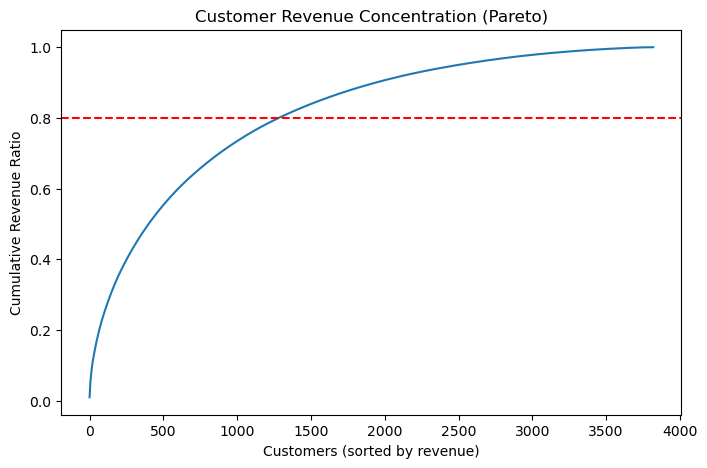

In [ ]:
# 고객 매출 집중도 그래프
# 고객별 매출 합계 계산
customer_sales = df.groupby("CustomerID")["TotalAmount"].sum().sort_values(ascending=False)

# 누적 비율 계산
cumulative_ratio = customer_sales.cumsum() / customer_sales.sum()

# 그래프
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(cumulative_ratio.values)
plt.axhline(0.8, color='red', linestyle='--')
plt.title("Customer Revenue Concentration (Pareto)")
plt.xlabel("Customers (sorted by revenue)")
plt.ylabel("Cumulative Revenue Ratio")
plt.show()

### 가로축: 매출이 높은 고객순부터 순서대로 나열한 고객 수 - 왼쪽 = 매출이 높은 고객, 오른쪽 = 매출이 낮은 고객
### 세로축: 누적 매출 비율 - 고객이 많아질수록 누적 매출 비율이 증가함
### 이 그래프는 고객 매출 집중도를 보여줍니다. 빨간 점선은 누적 매출 비율이 80%인 지점을 나타내며, 이 지점에서 고객 수가 전체의 몇 퍼센트를 차지하는지 확인할 수 있습니다. 일반적으로 상위 20% 고객이 전체 매출의 80%를 차지하는 경우가 많다는 것을 보여주는 그래프입니다.
### 왼쪽이 0인 건 정상이고, 초반에 급격히 올라가는 모양이 핵심입니다.

In [ ]:
# 상위 20% 고객 매출 비중 계산하는 코드
top_20 = int(len(customer_sales) * 0.2) # 전체 고객중 상위 20%가 몇 명인지 계산하는 코드

top_20_ratio = customer_sales.iloc[:top_20].sum() / customer_sales.sum() # 상위 20% 고객 매출이 전체 매출에서 차지하는 비율 계산하는 코드

print("상위 20% 고객 매출 비중:", round(top_20_ratio * 100, 2), "%") # 보기 편하게 %로 출력해주는 코드

상위 20% 고객 매출 비중: 66.21 %
